In [ ]:
!pip install kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"blossomspine","key":"9ab6979c60c7e62d7a3b8d19a212f189"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
 97% 190M/195M [00:00<00:00, 631MB/s] 
100% 195M/195M [00:00<00:00, 634MB/s]


In [ ]:
import os
import shutil

DATASET_PATH = "/content/data/Dataset_BUSI_with_GT"
OUTPUT_PATH = "/content/data/Dataset_BUSI_with_GT/train"

classes = ["benign", "malignant", "normal"]

os.makedirs(OUTPUT_PATH, exist_ok=True)

for cls in classes:
    src_folder = os.path.join(DATASET_PATH, cls)
    dst_folder = os.path.join(OUTPUT_PATH, cls.replace(" ", "_"))
    os.makedirs(dst_folder, exist_ok=True)

    # Only include image files, exclude mask files
    images = [
        f for f in os.listdir(src_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and "_mask" not in f.lower()
    ]

    for img in images:
        src_path = os.path.join(src_folder, img)
        dst_path = os.path.join(dst_folder, img)

        # Copy image
        shutil.copy2(src_path, dst_path)

    print(f"Class {cls}: {len(images)} images copied (without masks).")

print("All class images copied into train folder (mask images removed).")

Class benign: 437 images copied (without masks).
Class malignant: 210 images copied (without masks).
Class normal: 133 images copied (without masks).
All class images copied into train folder (mask images removed).


In [ ]:
train_dir = "/content/data/Dataset_BUSI_with_GT/train"

# **Data Visualization**

Classes: ['benign', 'malignant', 'normal']


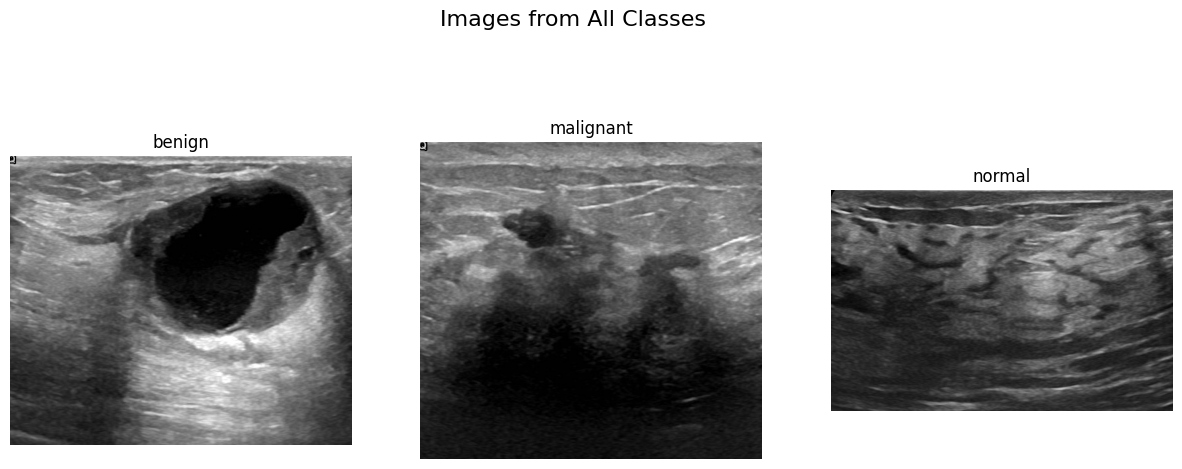

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

classes = os.listdir(train_dir)
print("Classes:", classes)

# Show one random image from each class
plt.figure(figsize=(15, 6))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)

    # Pick a random image from that class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Read image
    img = mpimg.imread(img_path)

    # Plot
    plt.subplot(1, 3, i+1)  # 1 row, 5 columns

    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Images from All Classes", fontsize=16)
plt.show()

/tmp/ipython-input-3315502790.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="label", y="count", data=df, palette=palette)


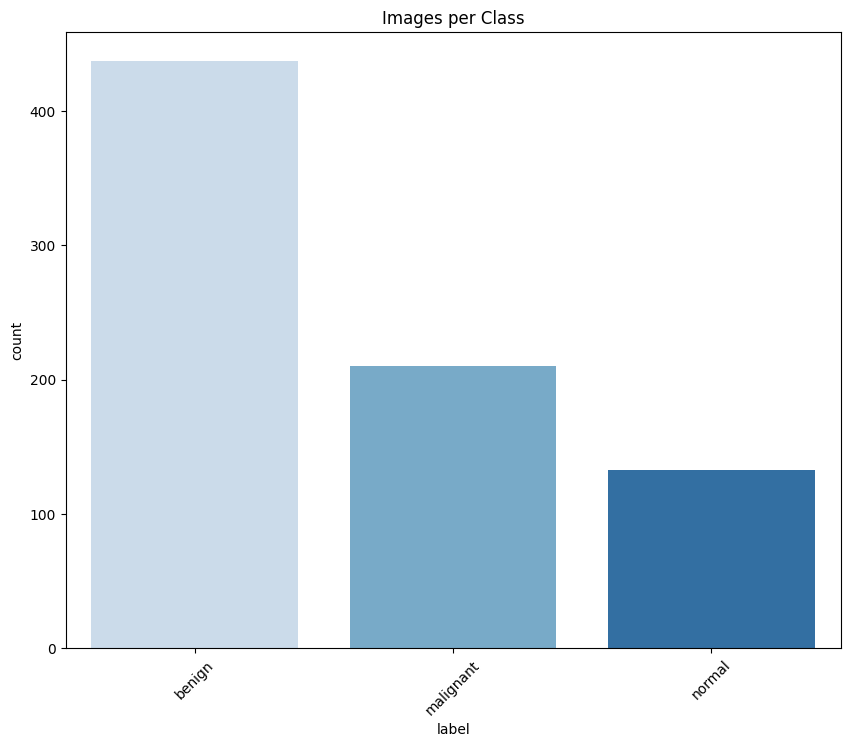

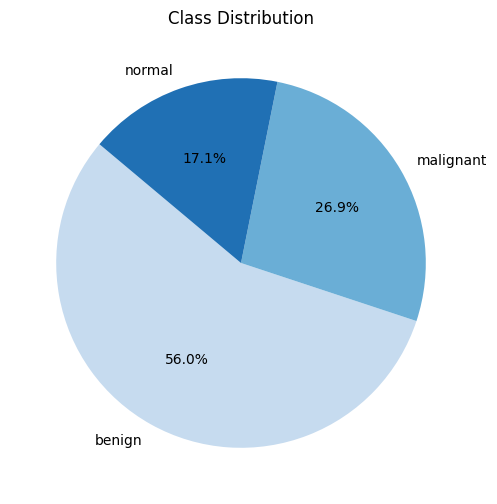

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count images per class
df = pd.DataFrame([(cls, len(os.listdir(os.path.join(train_dir, cls))))
                   for cls in os.listdir(train_dir)], columns=["label", "count"])

# Choose a blue-purple palette
palette = sns.color_palette("Blues", len(df))

# Bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x="label", y="count", data=df, palette=palette)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

# Pie chart
df.set_index("label")["count"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    figsize=(6, 6),
    colors=palette
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()


# **Over Sampling and Label Encoding**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import numpy as np
import os

# Data augmentation settings
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

target_count = 450  # max images per class

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    current_count = len(images)

    if current_count >= target_count:
        print(f"Skipping {cls}: {current_count} images already present.")
        continue

    needed = target_count - current_count
    print(f"Augmenting {cls}: generating {needed} images...")

    img_index = 0
    for _ in range(needed):
        img_path = os.path.join(cls_path, images[img_index % len(images)])
        img = np.expand_dims(np.array(Image.open(img_path).convert("RGB")), axis=0)
        aug_iter = datagen.flow(img, batch_size=1, save_to_dir=cls_path, save_prefix="aug", save_format="jpg")
        next(aug_iter)
        img_index += 1

print("✅ Data augmentation completed.\n")

# Print final class counts
for cls in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, cls)))
    print(f"{cls}: {count} images")

Skipping benign: 450 images already present.
Skipping malignant: 450 images already present.
Augmenting normal: generating 1 images...
✅ Data augmentation completed.

benign: 450 images
malignant: 450 images
normal: 450 images


In [ ]:
from sklearn.preprocessing import LabelEncoder
import os
import pandas as pd

encoder = LabelEncoder()
df["Label_num"] = encoder.fit_transform(df["label"])

image_paths = []
labels_num = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(cls_path):
        image_paths.append(os.path.join(cls_path, img_name))
        labels_num.append(encoder.transform([cls])[0])

df_balanced = pd.DataFrame({"image_path": image_paths, "label_num": labels_num})

print("Class counts after augmentation:")
print(df_balanced["label_num"].value_counts())

Class counts after augmentation:
label_num
0    450
1    450
2    450
Name: count, dtype: int64


# **Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split

df_balanced['label_num'] = df_balanced['label_num'].astype(str)

train_df, temp_df = train_test_split(df_balanced, train_size=0.8, shuffle=True,
                                     stratify=df_balanced['label_num'], random_state=42)

valid_df, test_df = train_test_split(temp_df, test_size=0.5, shuffle=True,
                                     stratify=temp_df['label_num'], random_state=42)

print("Train size:", train_df.shape)
print("Validation size:", valid_df.shape)
print("Test size:", test_df.shape)

Train size: (1080, 2)
Validation size: (135, 2)
Test size: (135, 2)


# **Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # ✅ use correct one

batch_size = 32
img_size = (224, 224)

# Training generator with augmentation
tr_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validation / Test generator
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Flow from dataframe
train_gen = tr_gen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label_num',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

valid_gen = ts_gen.flow_from_dataframe(
    valid_df,
    x_col='image_path',
    y_col='label_num',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size
)

test_gen = ts_gen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label_num',
    target_size=img_size,
    class_mode='sparse',
    color_mode='rgb',
    shuffle=False,
    batch_size=batch_size
)


Found 1080 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.
Found 135 validated image filenames belonging to 3 classes.


SE MobileNetV2


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Multiply, Reshape
from tensorflow.keras.optimizers import Adam

# Define SE Block
def se_block(input_tensor, reduction=16):
    channels = input_tensor.shape[-1]

    # Squeeze & Excitation
    se = GlobalAveragePooling2D()(input_tensor)  # Squeeze
    se = Dense(channels // reduction, activation='relu', use_bias=False)(se)
    se = Dense(channels, activation='sigmoid', use_bias=False)(se)
    se = Reshape((1, 1, channels))(se)

    return Multiply()([input_tensor, se])  # Excitation (scale input tensor)

# Create SE-MobileNetV2
def create_mobilenetv2_senet(input_shape=(224,224,3), num_classes=3):
    inputs = Input(shape=input_shape)

    # Pretrained MobileNetV2
    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)

    # Freeze initial layers, keep last 20 layers trainable
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output
    x = se_block(x)  # Apply SE block to MobileNetV2 output

    # Global pooling + classifier
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# Build and compile
model = create_mobilenetv2_senet(num_classes=3)
model.compile(optimizer=Adam(learning_rate=1e-4),  # higher LR
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/tmp/ipython-input-3056161766.py:23: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=inputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,253,827 (12.41 MB)

 Trainable params: 2,200,387 (8.39 MB)

 Non-trainable params: 1,053,440 (4.02 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,                  # stop if val_accuracy doesn't improve for 7 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,                  # reduce LR by 50% if plateau
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor='val_accuracy',
        save_best_only=True,         # save only best model
        verbose=1
    )
]

# Fit model
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,                       # increase epochs; callbacks will stop early if needed
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6694 - loss: 0.8511
Epoch 1: val_accuracy improved from -inf to 0.50370, saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.6696 - loss: 0.8507 - val_accuracy: 0.5037 - val_loss: 0.9494 - learning_rate: 1.0000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7141 - loss: 0.7298
Epoch 2: val_accuracy did not improve from 0.50370
34/34 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.7137 - loss: 0.7308 - val_accuracy: 0.4889 - val_loss: 0.9250 - learning_rate: 1.0000e-04
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7779 - loss: 0.5980
Epoch 3: val_accuracy improved from 0.50370 to 0.59259, saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7777 - loss: 0.5990 - val_accuracy: 0.5926 - val_loss: 0.8654 - learning_rate: 1.0000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7837 - loss: 0.5759
Epoch 4: val

In [ ]:
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model("best_model.keras")

# Evaluate on the test set
loss, accuracy = best_model.evaluate(test_gen, verbose=1)

# Print results
print(f"✅ Best Model Test Accuracy: {accuracy*100:.2f}%")
print(f"✅ Best Model Test Loss: {loss:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7879 - loss: 0.7259
✅ Best Model Test Accuracy: 77.78%
✅ Best Model Test Loss: 0.6949


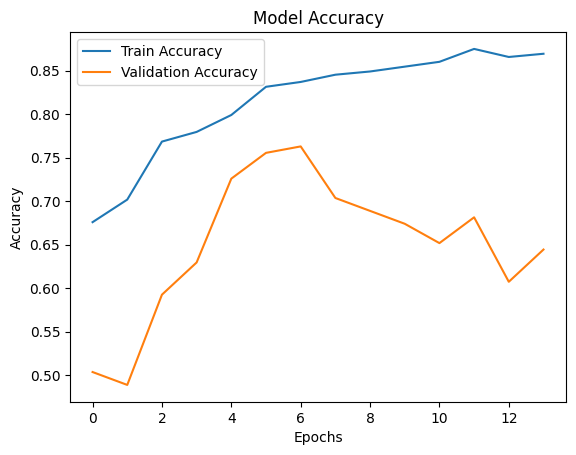

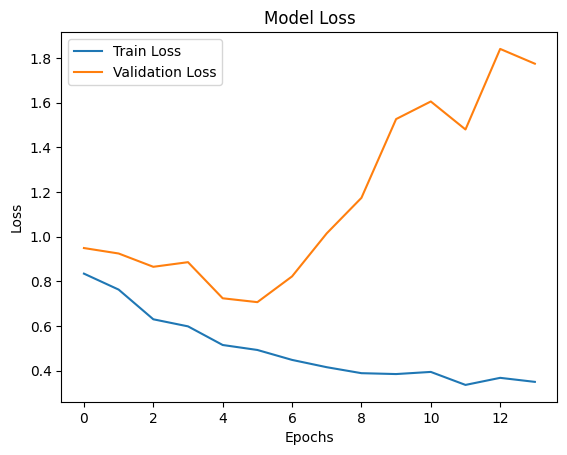

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.60      0.75        45
           1       0.65      0.87      0.74        45
           2       0.81      0.87      0.84        45

    accuracy                           0.78       135
   macro avg       0.82      0.78      0.78       135
weighted avg       0.82      0.78      0.78       135



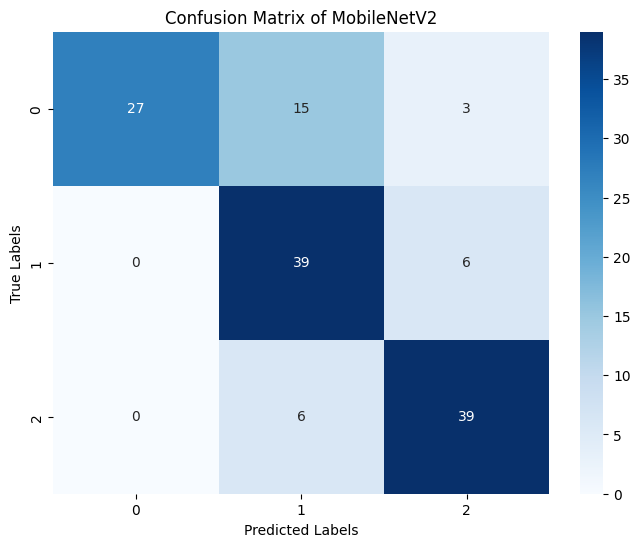

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# True labels
y_true = test_gen.classes

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1)

# Classification report
class_names = list(test_gen.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix of MobileNetV2")
plt.show()

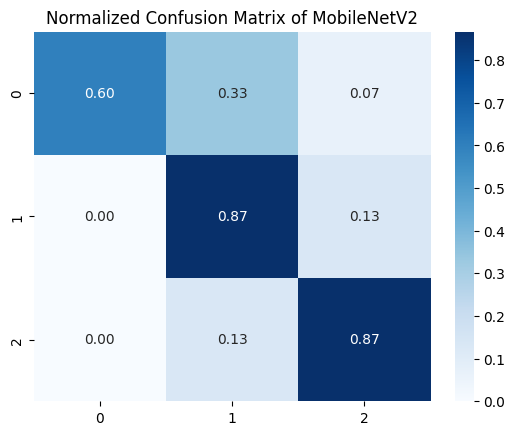

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.title("Normalized Confusion Matrix of MobileNetV2")
plt.show()


Grad-CAM for class 1: /content/data/Dataset_BUSI_with_GT/train/malignant/aug_0_5406.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


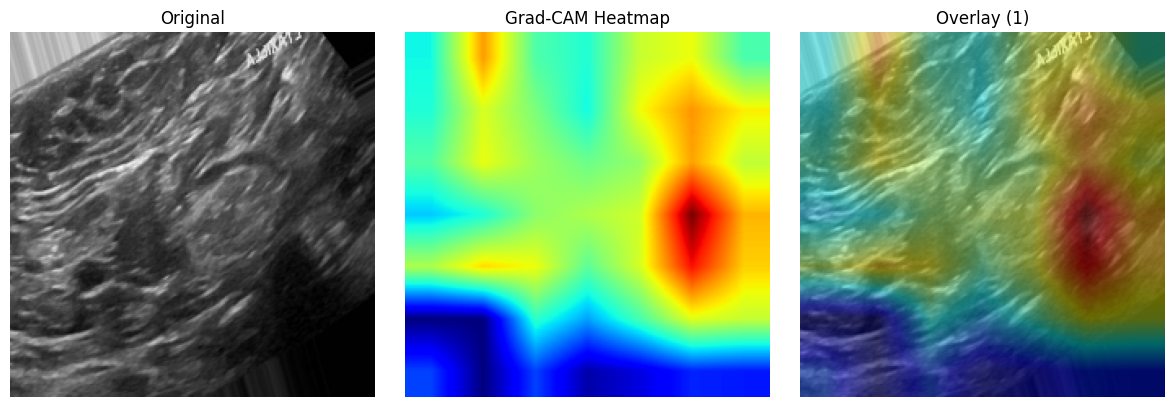

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class id: 1 | Probability: 0.827
True class: 1

Grad-CAM for class 0: /content/data/Dataset_BUSI_with_GT/train/benign/benign (315).png


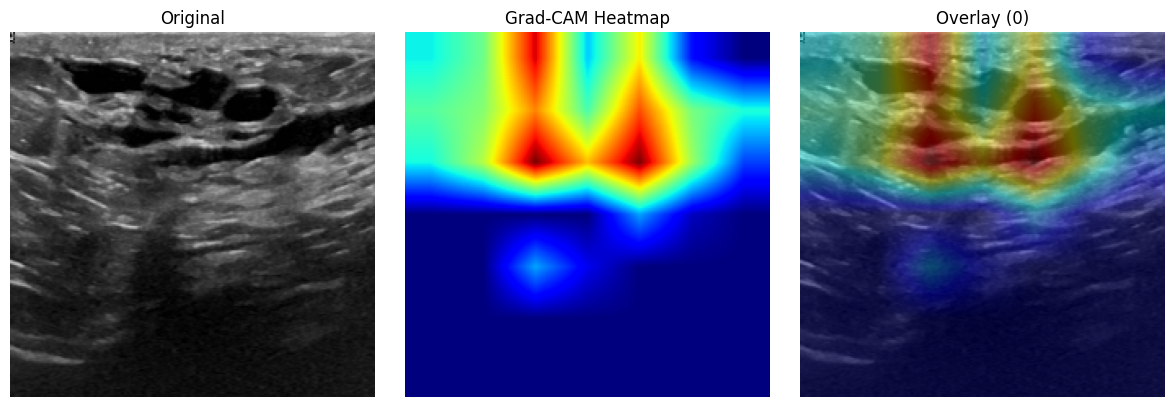

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted class id: 0 | Probability: 0.759
True class: 0

Grad-CAM for class 2: /content/data/Dataset_BUSI_with_GT/train/normal/aug_0_1380.jpg


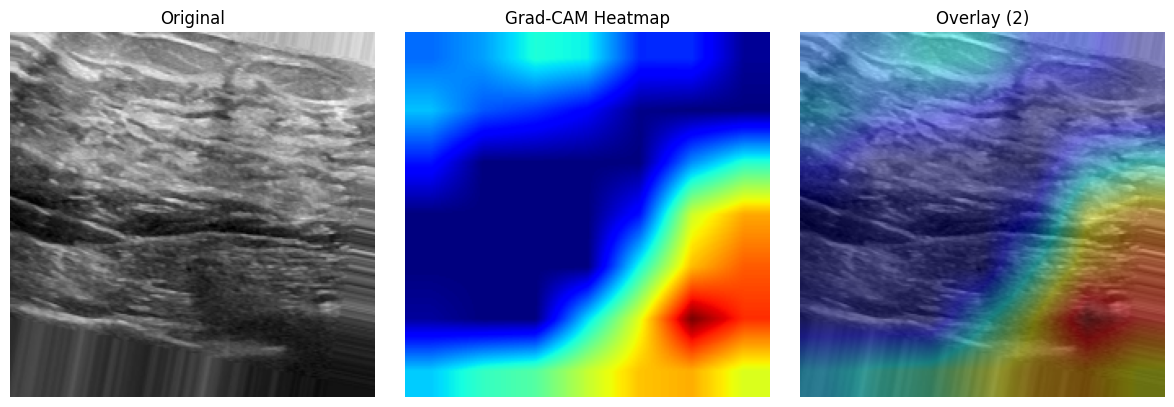

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted class id: 2 | Probability: 0.946
True class: 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import cv2

# ---------- Grad-CAM function ----------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1", pred_index=None):
    """
    Generates Grad-CAM heatmap for a single image.
    """
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ---------- Display function ----------
def display_gradcam(img_path, model, class_name=None, last_conv_layer_name="Conv_1", alpha=0.4):
    img_size = (224,224)
    # Load & preprocess
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_exp = tf.keras.applications.mobilenet_v2.preprocess_input(img_array_exp)

    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize and overlay
    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_uint8 = np.uint8(255*heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, img_size)
    overlay_img = cv2.addWeighted(original_img, 1-alpha, heatmap_color, alpha, 0)

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    title_str = "Overlay"
    if class_name:
        title_str += f" ({class_name})"
    plt.title(title_str)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Prediction info
    preds = model.predict(img_array_exp)
    pred_idx = np.argmax(preds)
    pred_prob = preds[0][pred_idx]
    print(f"Predicted class id: {pred_idx} | Probability: {pred_prob:.3f}")
    if class_name:
        print(f"True class: {class_name}")

# ---------- Pick one sample image per class ----------
class_ids = test_df['label_num'].unique()
sample_imgs = []
for cls in class_ids:
    img_path = test_df[test_df['label_num']==cls]['image_path'].iloc[0]
    sample_imgs.append((img_path, cls))

# ---------- Display Grad-CAM for each class ----------
for img_path, cls in sample_imgs:
    class_name = str(cls)  # optionally map to actual class names
    print(f"\nGrad-CAM for class {cls}: {img_path}")
    display_gradcam(img_path, best_model, class_name=class_name, last_conv_layer_name="Conv_1")
